# 05 - One Question, One Test, One Interpretation


## 1) Learning Objectives

- Connect population vs sample reasoning.
- Perform short exploratory data analysis (EDA).
- State H0 and H1 clearly.
- Run exactly one inferential test.
- Interpret p-value and confidence interval in plain language.

## 2) Why This Topic Matters

Good analysis starts with **one clear question**. Running many tests without planning increases the risk of false discoveries.

## 3) Our One Question

**Question:** Do students who use **Method A** and **Method B** have different average exam scores?

This fits Week 1 because we have:
- two groups,
- one numeric outcome,
- one test: independent two-sample t-test.

## 4) Step-by-Step Workflow

### Step 4.1 — Setup and create synthetic data

We simulate a sample of students from two teaching methods.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_theme(style='whitegrid')
rng = np.random.default_rng(42)

sample_size_each_group = 30
method_a_scores = rng.normal(loc=71, scale=9, size=sample_size_each_group)
method_b_scores = rng.normal(loc=77, scale=9, size=sample_size_each_group)

students = pd.DataFrame({
    'exam_score': np.concatenate([method_a_scores, method_b_scores]),
    'method': ['Method A'] * sample_size_each_group + ['Method B'] * sample_size_each_group,
})

students.head()

,exam_score,method
0,73.742454,Method A
1,61.640143,Method A
2,77.754061,Method A
3,79.465082,Method A
4,53.440683,Method A


### Step 4.2 — Short EDA

In [2]:
print('Sample size by method:')
print(students['method'].value_counts())
print('\nDescriptive statistics:')
students.groupby('method')['exam_score'].describe().round(2)

Sample size by method:
method
Method A    30
Method B    30
Name: count, dtype: int64

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
Method A,30.0,71.15,6.99,53.44,67.32,71.87,75.64,82.00
Method B,30.0,78.02,7.24,63.89,72.48,78.51,82.81,96.27


<Figure size 600x400 with 0 Axes>

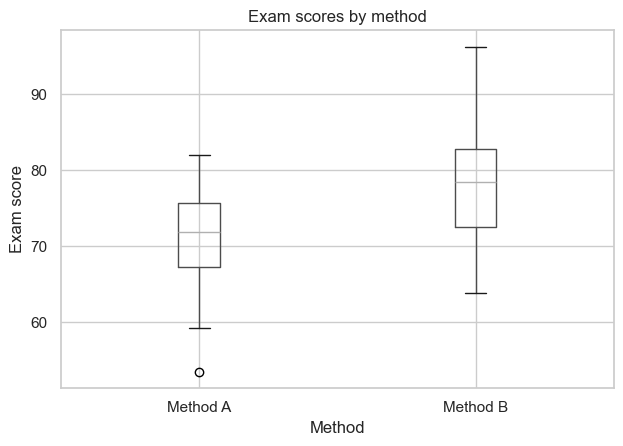

In [3]:
plt.figure(figsize=(6, 4))
students.boxplot(column='exam_score', by='method')
plt.title('Exam scores by method')
plt.suptitle('')
plt.xlabel('Method')
plt.ylabel('Exam score')
plt.tight_layout()
plt.show()

**Interpretation:** Method B appears higher on average, but sample variability remains visible in the boxplot.

### Step 4.3 — State hypotheses

- **H0:** Mean exam score is the same for Method A and Method B.
- **H1:** Mean exam scores are different between methods.

### Step 4.4 — One statistical test only (t-test)

In [4]:
a_scores = students.loc[students['method'] == 'Method A', 'exam_score']
b_scores = students.loc[students['method'] == 'Method B', 'exam_score']

t_result = stats.ttest_ind(a_scores, b_scores, equal_var=False)
print('t statistic:', round(t_result.statistic, 3))
print('p-value:', round(t_result.pvalue, 4))

t statistic: -3.74
p-value: 0.0004


### Step 4.5 — Confidence interval for mean difference

In [5]:
mean_diff = b_scores.mean() - a_scores.mean()
se_diff = np.sqrt(a_scores.var(ddof=1)/len(a_scores) + b_scores.var(ddof=1)/len(b_scores))
df_num = (a_scores.var(ddof=1)/len(a_scores) + b_scores.var(ddof=1)/len(b_scores)) ** 2
df_den = ((a_scores.var(ddof=1)/len(a_scores))**2 / (len(a_scores)-1)) + ((b_scores.var(ddof=1)/len(b_scores))**2 / (len(b_scores)-1))
degrees_freedom = df_num / df_den
t_critical = stats.t.ppf(0.975, degrees_freedom)
margin = t_critical * se_diff
ci_low = mean_diff - margin
ci_high = mean_diff + margin

print('Mean difference (B - A):', round(mean_diff, 2))
print('95% confidence interval: [', round(ci_low, 2), ',', round(ci_high, 2), ']')

Mean difference (B - A): 6.87
95% confidence interval: [ 3.19 , 10.55 ]


**Interpretation:** The confidence interval gives a range of plausible values for the true mean difference. If 0 is not inside the interval, that supports a difference.

### Step 4.6 — Plain-language conclusion

In [6]:
alpha = 0.05
if t_result.pvalue < alpha:
    conclusion = (
        'We reject H0 at alpha = 0.05. The data suggest Method A and Method B '
        'have different average exam scores in this sample.'
    )
else:
    conclusion = (
        'We do not reject H0 at alpha = 0.05. The observed difference could be due to random sampling variation.'
    )
print(conclusion)

We reject H0 at alpha = 0.05. The data suggest Method A and Method B have different average exam scores in this sample.


### Step 4.7 — Change sample size or group difference

In [7]:
small_sample_a = rng.normal(71, 9, 10)
small_sample_b = rng.normal(77, 9, 10)
_, p_small = stats.ttest_ind(small_sample_a, small_sample_b, equal_var=False)

large_sample_a = rng.normal(71, 9, 200)
large_sample_b = rng.normal(77, 9, 200)
_, p_large = stats.ttest_ind(large_sample_a, large_sample_b, equal_var=False)

size_effect = pd.DataFrame({
    'sample_size_per_group': [10, 200],
    'p_value': [p_small, p_large],
}).round(4)
size_effect

,sample_size_per_group,p_value
0,10,0.19
1,200,0.00


**Interpretation:** With larger samples, we usually get stronger evidence (smaller p-values) for the same underlying difference.

## 7) Summary Interpretation

We followed one clear question from EDA to a single t-test, confidence interval, and plain-language conclusion.

## 8) Student Check Questions

1. (Conceptual) Why avoid many tests without one clear question?

2. (Code) Change `sample_size_each_group` to 10 and rerun the t-test.

In [8]:
# Question 2 — your code here


## 9) Key Takeaways

- Start with one focused question.
- Explore data briefly before testing.
- Report estimate + uncertainty, not only p-values.
- Write conclusions in plain language.

## 10) Optional Short Practice / Challenge

Rewrite the final conclusion in plain language.

## 11) Code Refinement Tasks

Edit the code, rerun each cell, and write one short sentence per task.

1. Set `sample_size_each_group = 10` and rerun the t-test.
2. Use similar means (75 vs 76) and rerun the t-test.

In [9]:
# Refinement 1


In [10]:
# Refinement 2


In [11]:
print('Notebook 05 completed successfully.')

Notebook 05 completed successfully.
